In [1]:
import pandas as pd
import numpy as np
import itertools
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('news_dataset.csv', index_col=None)

In [3]:
df

,title,text,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,real
1,To offer down resource great point.,probably guess western behind likely next inve...,fake
2,Himself church myself carry.,them identify forward present success risk sev...,fake
3,You unit its should.,phone which item yard Republican safe where po...,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,fake
...,...,...,...
19995,House party born.,hit and television I change very our happy doo...,fake
19996,Though nation people maybe price box.,fear most meet rock even sea value design stan...,real
19997,Yet exist with experience unit.,activity loss very provide eye west create wha...,real
19998,School wide itself item.,term point general common training watch respo...,fake


In [4]:
dataset=df

In [5]:
y=dataset["label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(dataset['text'], y, test_size=0.33, random_state=53)

In [7]:
tf_idf_vectorizer=TfidfVectorizer(stop_words='english')  # stop_words like is,was,the,in etc will be removed
tfidf_train=tf_idf_vectorizer.fit_transform(X_train) # fit method creates model. fit_transform creates model + predict
print(tfidf_train)
tfidf_test=tf_idf_vectorizer.transform(X_test) # convert the new text into the same numerical format that was already learned from the training data.

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2321047 stored elements and shape (13400, 763)>
  Coords	Values
  (0, 410)	0.14002656787292253
  (0, 134)	0.07048449599174575
  (0, 60)	0.06953147960237512
  (0, 502)	0.13853266637381845
  (0, 230)	0.0700506909200381
  (0, 122)	0.06986415294085428
  (0, 327)	0.0700319811916731
  (0, 583)	0.07038961808739426
  (0, 507)	0.0694764156806706
  (0, 136)	0.0690758834599593
  (0, 7)	0.06985485853090045
  (0, 475)	0.0694489242080112
  (0, 408)	0.06966961425255727
  (0, 545)	0.07035175661451085
  (0, 582)	0.06966038407910585
  (0, 169)	0.0697713471586877
  (0, 728)	0.1397097170618009
  (0, 379)	0.06966961425255727
  (0, 133)	0.06983627894639914
  (0, 650)	0.07054157718196358
  (0, 27)	0.06965115694239521
  (0, 155)	0.06964193284042781
  (0, 687)	0.14171523487778961
  (0, 275)	0.06966961425255727
  (0, 74)	0.06913016582873525
  :	:
  (13399, 120)	0.0657890981404117
  (13399, 50)	0.06509488697577527
  (13399, 233)	0.06485320158008981
  

In [9]:
dir(tfidf_train)

['T',
 '__abs__',
 '__abstractmethods__',
 '__add__',
 '__array_priority__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__div__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__idiv__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__pow__',
 '__radd__',
 '__rdiv__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmatmul__',
 '__rmul__',
 '__round__',
 '__rsub__',
 '__rtruediv__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_abc_impl',
 '_add_dense',
 '_add_sparse',
 '_allow_nd',
 '_argminmax',
 '_argminmax_axis',
 '_ascontainer'

In [11]:
len(tf_idf_vectorizer.get_feature_names_out())

763

In [12]:
print(tfidf_train.toarray())

[[0.06851217 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.05796141 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.07340748 0.07254641 0.        ]
 [0.         0.         0.         ... 0.         0.07259474 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [13]:
# MultinomialNB

In [14]:
clf=MultinomialNB()
clf.fit(tfidf_train, y_train)
pred=clf.predict(tfidf_test)
score=metrics.accuracy_score(y_test, pred)
print("accuracy: %0.3f" %score)

cm=metrics.confusion_matrix(y_test, pred, labels=['fake','real'])

accuracy: 0.504


In [15]:
from sklearn.metrics import classification_report
report=classification_report(y_test,pred)
print(report)

              precision    recall  f1-score   support

        fake       0.51      0.61      0.55      3329
        real       0.50      0.39      0.44      3271

    accuracy                           0.50      6600
   macro avg       0.50      0.50      0.50      6600
weighted avg       0.50      0.50      0.50      6600



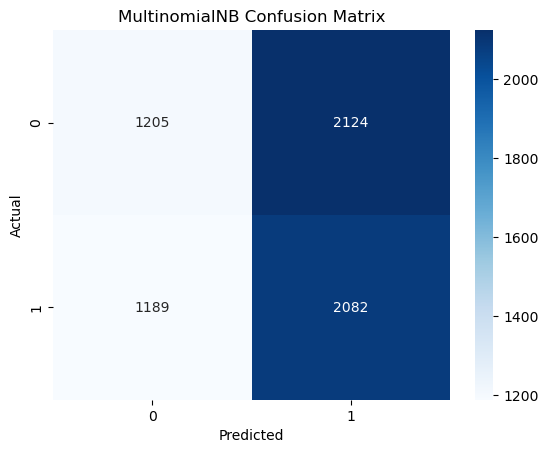

In [20]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('MultinomialNB Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
# PassiveAggressiveClassifier

In [16]:
clf_1=PassiveAggressiveClassifier()
clf_1.fit(tfidf_train, y_train)
pred=clf_1.predict(tfidf_test)
score=metrics.accuracy_score(y_test, pred)
print("accuracy: %0.3f" %score)

cm=metrics.confusion_matrix(y_test, pred, labels=['fake','real'])

accuracy: 0.498
